

<font face="Times New Roman" size=5>
<div dir=rtl align="center">


<font face="Times New Roman" size=4 align=center>
Sharif University of Technology - Department of Nano
</font>
<br>
<font color="#008080" size=6>
Introduction to Machine Learning
</font>

<hr/>
<font color="#80a080" size=5>
Course Home Work 4
<br>
</font>
<font size=5>
Instructor: Dr. Ebrahim Pour
<br>
</font>
<font size=4>
Spring 2026
<br>
</font>





> **Student**:
>
> Kian Mamdouhi: 400108066

### Imports

In [91]:
from scipy.io import loadmat
from scipy.cluster.hierarchy import linkage, fcluster   
from scipy.spatial.distance import cdist               
import matplotlib.pyplot as plt
import numpy as np
import time
import math
from PIL import Image   

### Load data

In [92]:
path =  "C:/term10\ML/tamrin\HW4\Data_hoda_full.mat"
data = loadmat(path)
print(data.keys())
all_image = data['Data']
all_label = data['labels']

dict_keys(['__header__', '__version__', '__globals__', 'Data', 'labels'])


### Load & grayscale first 4000 images

In [93]:
N = 4000
raw_images = np.empty(N, dtype=object)
labels = np.empty(N, dtype=np.int32)
heights, widths = [], []

for i in range(N):
    img = all_image[i, 0]
    label = int(all_label[i, 0])
    gray = np.array(Image.fromarray(img).convert('L'))
    raw_images[i] = gray
    labels[i] = label
    h, w = gray.shape
    heights.append(h)
    widths.append(w)

max_height = max(heights)
max_width = max(widths)
print(f"h_max = {max_height}, w_max = {max_width}")

h_max = 54, w_max = 45


### Center-pad all images to max size

In [94]:
images = np.zeros((N, max_height, max_width), dtype=np.uint8)
for i, gray in enumerate(raw_images):
    h, w = gray.shape
    y = (max_height - h) // 2
    x = (max_width - w) // 2
    images[i, y:y+h, x:x+w] = gray

### Display one sample per class

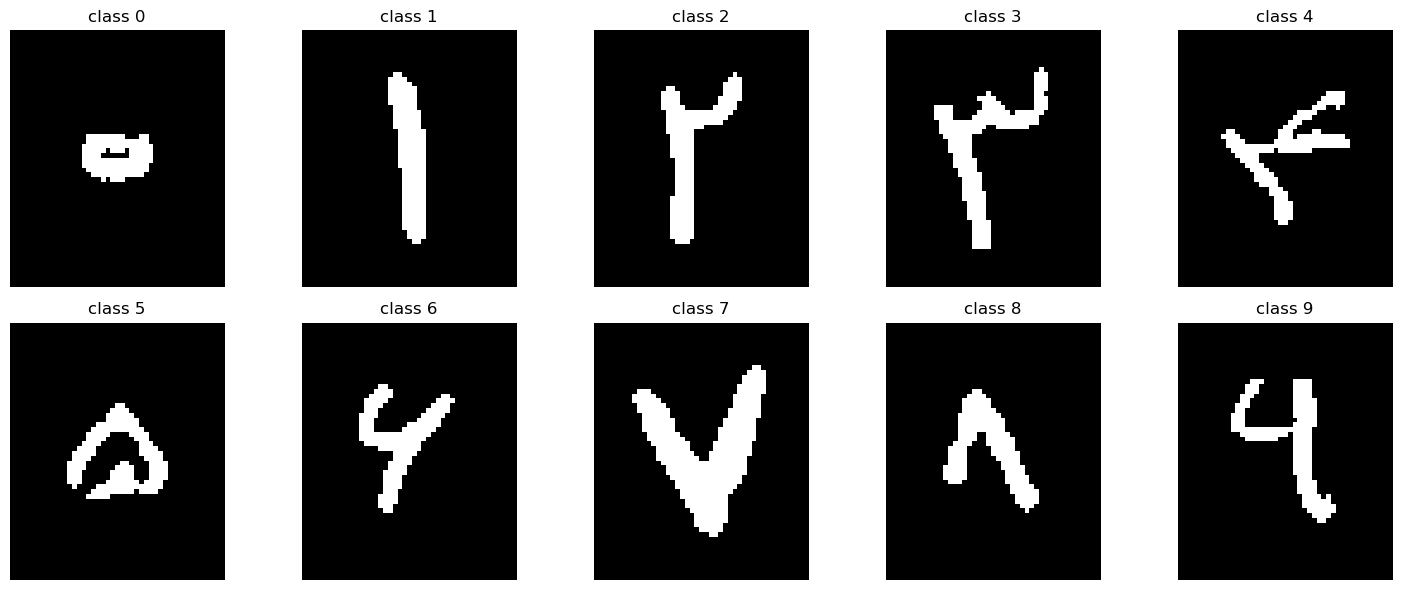

Representative indices: [np.int64(2), np.int64(62), np.int64(3), np.int64(12), np.int64(22), np.int64(1), np.int64(0), np.int64(4), np.int64(28), np.int64(19)]


In [95]:
def display_class_samples(images, labels, num_classes=10, per_row=5):
    indices = []
    for c in range(num_classes):
        class_idx = np.where(labels == c)[0]
        indices.append(None if len(class_idx) == 0 else class_idx[0])
    rows = math.ceil(num_classes / per_row)
    plt.figure(figsize=(per_row*3, rows*3))
    for i, idx in enumerate(indices):
        if idx is None:
            continue
        plt.subplot(rows, per_row, i+1)
        plt.imshow(images[idx], cmap='gray')
        plt.title(f"class {i}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
    return indices

rep_indices = display_class_samples(images, labels)
print("Representative indices:", rep_indices)

### Feature extraction

In [96]:
def zoning_features_batch(imgs, zones=6):
    N, H, W = imgs.shape
    zh = H // zones
    zw = W // zones
    cropped  = imgs[:, :zh*zones, :zw*zones]
    reshaped = cropped.reshape(N, zones, zh, zones, zw)
    features = (reshaped > 0).sum(axis=(2, 4)) 
    return features.reshape(N, -1).astype(np.float32)


def histogram_features_batch(imgs):
    binary = imgs > 0
    horizontal = binary.sum(axis=2)
    vertical = binary.sum(axis=1)
    return np.hstack([horizontal, vertical]).astype(np.float32)


def zoning_features(image, zones=6):
    h, w = image.shape
    zh, zw = h // zones, w // zones
    cropped = image[:zh*zones, :zw*zones]
    reshaped = cropped.reshape(zones, zh, zones, zw)
    return (reshaped > 0).sum(axis=(1, 3)).flatten().astype(np.float32)


def histogram_features(image):
    binary = image > 0
    return np.concatenate([binary.sum(axis=1), binary.sum(axis=0)]).astype(np.float32)


In [97]:
ts = time.time()
X_zoning = zoning_features_batch(images)
X_hist = histogram_features_batch(images)
te = time.time()
X_train_zoning, X_val_zoning = X_zoning[:3000], X_zoning[3000:]
X_train_hist, X_val_hist = X_hist[:3000], X_hist[3000:]
y_train, y_val = labels[:3000], labels[3000:]
print("X_zoning shape:", X_zoning.shape)
print("X_train_zoning shape:", X_train_zoning.shape)
print("X_hist shape:", X_hist.shape)
print('Feature extraction time:', te - ts)

X_zoning shape: (4000, 36)
X_train_zoning shape: (3000, 36)
X_hist shape: (4000, 99)
Feature extraction time: 0.06275081634521484


In [98]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_zoning = scaler.fit_transform(X_train_zoning)
X_val_zoning = scaler.transform(X_val_zoning)

### K-Means

In [99]:
def kmeans(X, K, max_iter=100, tol=1e-4, seed=42):
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=np.float64)
    n, nf = X.shape
    init_idx = rng.choice(n, size=K, replace=False)
    centroids = X[init_idx].copy()
    lab = np.zeros(n, dtype=np.int32)
    X_sq = np.einsum('ij,ij->i', X, X)
    for _ in range(max_iter):
        C_sq = np.einsum('ij,ij->i', centroids, centroids)
        dists = X_sq[:, None] + C_sq[None, :] - 2.0 * (X @ centroids.T)
        np.maximum(dists, 0, out=dists)
        new_lab = np.argmin(dists, axis=1)
        new_c = np.zeros_like(centroids)
        counts = np.bincount(new_lab, minlength=K)
        np.add.at(new_c, new_lab, X)
        empty = counts == 0
        new_c[~empty] /= counts[~empty, None]
        if empty.any():
            new_c[empty] = X[rng.integers(0, n, size=int(empty.sum()))]
        shift = float(np.sqrt(np.sum((new_c - centroids) ** 2)))
        centroids = new_c
        lab = new_lab
        if shift < tol:
            break

    diff = X - centroids[lab]
    sse = float(np.einsum('ij,ij->', diff, diff))
    return lab, centroids, sse

### Cluster validity indices

In [100]:
def dunn_index(X, labels):
    X, labels = np.asarray(X, np.float64), np.asarray(labels)
    uniq = np.unique(labels)
    K = len(uniq)
    if K < 2:
        return np.nan
    clusters = [X[labels == k] for k in uniq]
    max_intra = 0.0
    for pts in clusters:
        if len(pts) < 2:
            continue
        diam = cdist(pts, pts).max()
        if diam > max_intra:
            max_intra = float(diam)
            
    if max_intra == 0.0:
        return np.inf
    min_inter = np.inf
    for i in range(K):
        for j in range(i + 1, K):
            d = cdist(clusters[i], clusters[j]).min()
            if d < min_inter:
                min_inter = float(d)

    return float(min_inter / max_intra)


def davies_bouldin_index(X, labels):
    X, labels = np.asarray(X, np.float64), np.asarray(labels)
    uniq = np.unique(labels)
    K = len(uniq)
    if K < 2:
        return np.nan
    centroids = np.array([X[labels == k].mean(axis=0) for k in uniq])
    S = np.array([cdist(X[labels == k], centroids[i:i+1]).mean() for i, k in enumerate(uniq)])
    M = cdist(centroids, centroids)
    with np.errstate(divide='ignore', invalid='ignore'):
        R = (S[:, None] + S[None, :]) / M
    np.fill_diagonal(R, -np.inf)
    return float(np.mean(np.max(R, axis=1)))


def silhouette_score_custom(X, labels):
    X, labels = np.asarray(X, np.float64), np.asarray(labels)
    n = X.shape[0]
    uniq = np.unique(labels)
    if len(uniq) < 2 or n < 2:
        return np.nan
    D = cdist(X, X)
    a = np.zeros(n)
    b = np.full(n, np.inf)
    for k in uniq:
        mask = labels == k
        cnt = mask.sum()
        if cnt > 1:
            a[mask] = D[np.ix_(mask, mask)].sum(axis=1) / (cnt - 1)
        for k2 in uniq:
            if k2 == k:
                continue
            mask2 = labels == k2
            if not mask2.any():
                continue
            mean_d = D[np.ix_(mask, mask2)].mean(axis=1)
            b[mask] = np.minimum(b[mask], mean_d)

    denom = np.maximum(a, b)
    s = np.where((denom == 0) | np.isinf(b), 0.0, (b - a) / denom)
    return float(np.mean(s))

### Zoning features

In [101]:
K_min, K_max = 2, 15
n_init = 5
max_iter = 100
tol = 1e-4
base_seed = 42
X = X_train_zoning
Ks = list(range(K_min, K_max + 1))
best_sse_list, dunn_list, dbi_list, sil_list = [], [], [], []
best_labels_per_k, best_centroids_per_k = {}, {}
t_total_start = time.time()
for K in Ks:
    best_sse, best_labels, best_centroids = np.inf, None, None
    t_km = time.time()
    for t in range(n_init):
        seed = base_seed + 1000*K + t
        lk, ck, sk = kmeans(X, K, max_iter=max_iter, tol=tol, seed=seed)
        if sk < best_sse:
            best_sse, best_labels, best_centroids = sk, lk, ck
    kmeans_time = time.time() - t_km
    t0 = time.time(); dunn_k = dunn_index(X, best_labels); dunn_time = time.time()-t0
    t0 = time.time(); dbi_k = davies_bouldin_index(X, best_labels); dbi_time = time.time()-t0
    t0 = time.time(); sil_k = silhouette_score_custom(X, best_labels); sil_time = time.time()-t0
    best_sse_list.append(best_sse)
    dunn_list.append(dunn_k)
    dbi_list.append(dbi_k)
    sil_list.append(sil_k)
    best_labels_per_k[K] = best_labels
    best_centroids_per_k[K] = best_centroids
    print(f"K={K:2d} | SSE={best_sse:.4f} | Dunn={dunn_k:.4f} | DBI={dbi_k:.4f} | Sil={sil_k:.4f}"
    f"  time(s): kmeans={kmeans_time:.2f}, dunn={dunn_time:.2f},"
    f" dbi={dbi_time:.2f}, sil={sil_time:.2f}"
    f" -> total={kmeans_time+dunn_time+dbi_time+sil_time:.2f}")
    
print(f"\nTotal runtime for K={K_min}..{K_max} (n_init={n_init}): "
f"{time.time()-t_total_start:.2f} seconds")

K= 2 | SSE=99211.3588 | Dunn=0.0397 | DBI=2.4578 | Sil=0.7024  time(s): kmeans=0.26, dunn=0.16, dbi=0.00, sil=0.20 -> total=0.62
K= 3 | SSE=93270.8227 | Dunn=0.0092 | DBI=2.4415 | Sil=0.1736  time(s): kmeans=0.11, dunn=0.12, dbi=0.00, sil=0.21 -> total=0.45
K= 4 | SSE=86700.7591 | Dunn=0.0091 | DBI=2.1581 | Sil=0.1619  time(s): kmeans=0.26, dunn=0.11, dbi=0.00, sil=0.20 -> total=0.58
K= 5 | SSE=81703.2886 | Dunn=0.0080 | DBI=2.1501 | Sil=0.1624  time(s): kmeans=0.23, dunn=0.13, dbi=0.00, sil=0.18 -> total=0.54
K= 6 | SSE=77499.1950 | Dunn=0.0083 | DBI=1.9790 | Sil=0.1630  time(s): kmeans=0.20, dunn=0.11, dbi=0.00, sil=0.19 -> total=0.51
K= 7 | SSE=75359.1134 | Dunn=0.0062 | DBI=2.0048 | Sil=0.0868  time(s): kmeans=0.27, dunn=0.09, dbi=0.00, sil=0.21 -> total=0.57
K= 8 | SSE=73119.1185 | Dunn=0.0054 | DBI=1.9595 | Sil=0.1044  time(s): kmeans=0.20, dunn=0.09, dbi=0.00, sil=0.20 -> total=0.49
K= 9 | SSE=69286.3044 | Dunn=0.0106 | DBI=1.9225 | Sil=0.1757  time(s): kmeans=0.24, dunn=0.10, d

### Plots

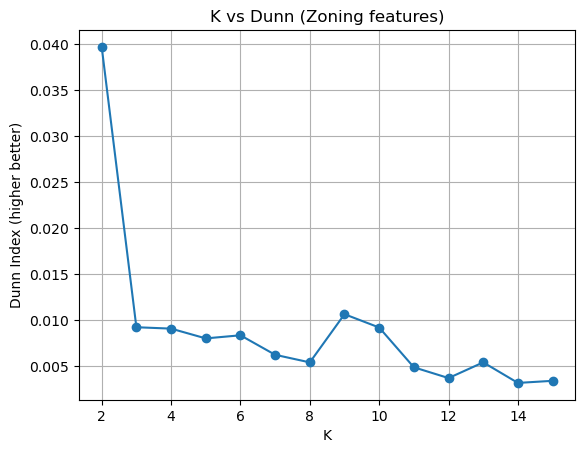

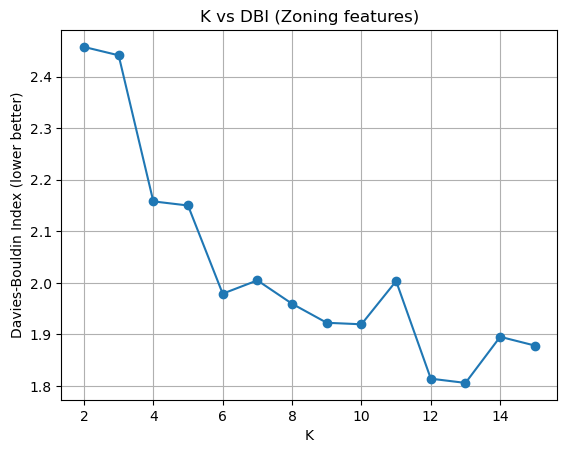

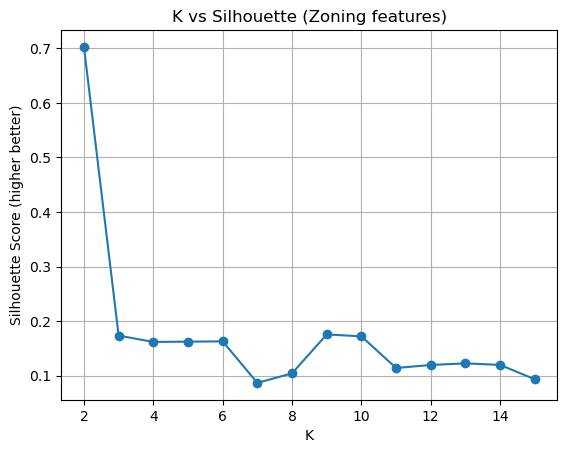

In [102]:
for values, ylabel, title in [
    (dunn_list, "Dunn Index (higher better)", "K vs Dunn (Zoning features)"),
    (dbi_list, "Davies-Bouldin Index (lower better)", "K vs DBI (Zoning features)"),
    (sil_list, "Silhouette Score (higher better)", "K vs Silhouette (Zoning features)"),
]:
    plt.figure()
    plt.plot(Ks, values, marker='o')
    plt.xlabel("K"); plt.ylabel(ylabel); plt.title(title); plt.grid(True)
plt.show()

### Rank-based K suggestion

In [103]:
dunn_rank = np.argsort(np.argsort(-np.array(dunn_list))) + 1
sil_rank = np.argsort(np.argsort(-np.array(sil_list))) + 1
dbi_rank = np.argsort(np.argsort( np.array(dbi_list))) + 1
total_rank = dunn_rank + sil_rank + dbi_rank
K_suggest = Ks[int(np.argmin(total_rank))]
print("\nRank-based suggestion:")
print("Ks:", Ks)
print("Dunn ranks:", dunn_rank.tolist())
print("Sil ranks:", sil_rank.tolist())
print("DBI ranks:", dbi_rank.tolist())
print("Total:", total_rank.tolist())
print(f"Suggested K (min total rank) = {K_suggest}")


Rank-based suggestion:
Ks: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Dunn ranks: [1, 3, 5, 7, 6, 8, 10, 2, 4, 11, 12, 9, 14, 13]
Sil ranks: [1, 3, 7, 6, 5, 14, 12, 2, 4, 11, 10, 8, 9, 13]
DBI ranks: [14, 13, 12, 11, 8, 10, 7, 6, 5, 9, 2, 1, 4, 3]
Total: [16, 19, 24, 24, 19, 32, 29, 10, 13, 31, 24, 18, 27, 29]
Suggested K (min total rank) = 9


### Histogram features

In [104]:
base_seed = 123
X = X_train_hist
best_sse_list, dunn_list, dbi_list, sil_list = [], [], [], []
best_labels_per_k, best_centroids_per_k = {}, {}
t_total_start = time.time()
for K in Ks:
    best_sse, best_labels, best_centroids = np.inf, None, None
    t_km = time.time()
    for t in range(n_init):
        seed = base_seed + 1000*K + t
        lk, ck, sk = kmeans(X, K, max_iter=max_iter, tol=tol, seed=seed)
        if sk < best_sse:
            best_sse, best_labels, best_centroids = sk, lk, ck
    kmeans_time = time.time() - t_km
    t0 = time.time(); dunn_k = dunn_index(X, best_labels); dunn_time = time.time()-t0
    t0 = time.time(); dbi_k = davies_bouldin_index(X, best_labels); dbi_time = time.time()-t0
    t0 = time.time(); sil_k = silhouette_score_custom(X, best_labels); sil_time = time.time()-t0
    best_sse_list.append(best_sse)
    dunn_list.append(dunn_k)
    dbi_list.append(dbi_k)
    sil_list.append(sil_k)
    best_labels_per_k[K] = best_labels
    best_centroids_per_k[K] = best_centroids
    print(f"K={K:2d} | SSE={best_sse:.4f} | Dunn={dunn_k:.4f} | DBI={dbi_k:.4f} | Sil={sil_k:.4f}"
    f"  time(s): kmeans={kmeans_time:.2f}, dunn={dunn_time:.2f},"
    f" dbi={dbi_time:.2f}, sil={sil_time:.2f}"
    f" -> total={kmeans_time+dunn_time+dbi_time+sil_time:.2f}")

print(f"\nTotal runtime for HISTOGRAM features (K={K_min}..{K_max}, n_init={n_init}): "
f"{time.time()-t_total_start:.2f} seconds")

K= 2 | SSE=3519076.3399 | Dunn=0.0533 | DBI=1.9158 | Sil=0.1644  time(s): kmeans=0.40, dunn=0.27, dbi=0.00, sil=0.34 -> total=1.01
K= 3 | SSE=3155374.8105 | Dunn=0.0536 | DBI=2.0668 | Sil=0.1684  time(s): kmeans=0.78, dunn=0.22, dbi=0.00, sil=0.35 -> total=1.35
K= 4 | SSE=2888618.3646 | Dunn=0.0543 | DBI=1.8544 | Sil=0.1859  time(s): kmeans=0.30, dunn=0.22, dbi=0.00, sil=0.36 -> total=0.88
K= 5 | SSE=2676072.0346 | Dunn=0.0419 | DBI=1.8244 | Sil=0.1337  time(s): kmeans=0.70, dunn=0.22, dbi=0.00, sil=0.36 -> total=1.29
K= 6 | SSE=2535534.2249 | Dunn=0.0419 | DBI=1.8577 | Sil=0.1353  time(s): kmeans=0.45, dunn=0.21, dbi=0.00, sil=0.36 -> total=1.03
K= 7 | SSE=2388766.0887 | Dunn=0.0530 | DBI=1.7425 | Sil=0.1419  time(s): kmeans=0.99, dunn=0.22, dbi=0.00, sil=0.40 -> total=1.61
K= 8 | SSE=2308500.8895 | Dunn=0.0543 | DBI=1.8368 | Sil=0.1244  time(s): kmeans=1.00, dunn=0.29, dbi=0.01, sil=0.74 -> total=2.05
K= 9 | SSE=2230041.1510 | Dunn=0.0543 | DBI=1.8352 | Sil=0.1338  time(s): kmeans=0.

### Plots

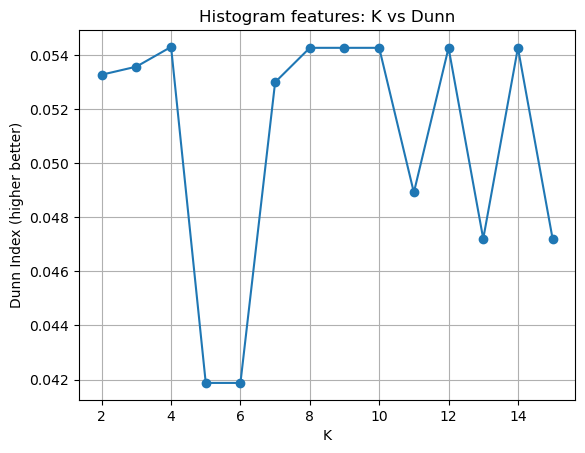

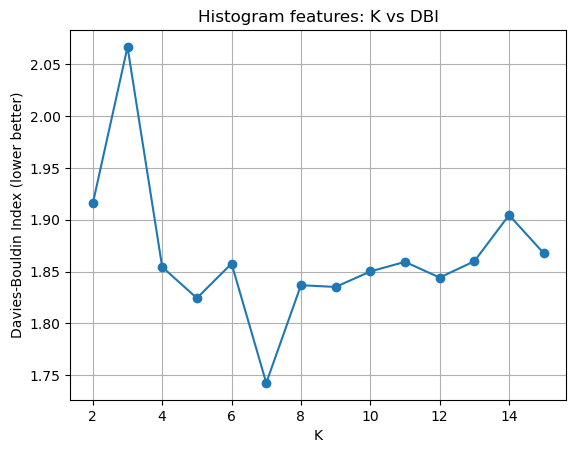

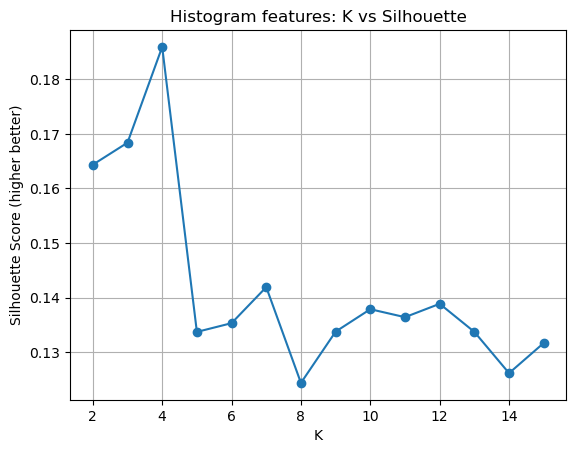

In [105]:
for values, ylabel, title in [
    (dunn_list, "Dunn Index (higher better)", "Histogram features: K vs Dunn"),
    (dbi_list, "Davies-Bouldin Index (lower better)", "Histogram features: K vs DBI"),
    (sil_list, "Silhouette Score (higher better)", "Histogram features: K vs Silhouette"),
]:
    plt.figure()
    plt.plot(Ks, values, marker='o')
    plt.xlabel("K"); plt.ylabel(ylabel); plt.title(title); plt.grid(True)
plt.show()

### Rank-based K suggestion for histogram

In [106]:
dunn_rank = np.argsort(np.argsort(-np.array(dunn_list))) + 1
sil_rank = np.argsort(np.argsort(-np.array(sil_list))) + 1
dbi_rank = np.argsort(np.argsort( np.array(dbi_list))) + 1
total_rank = dunn_rank + sil_rank + dbi_rank
K_suggest = Ks[int(np.argmin(total_rank))]
print("\nRank-based suggestion for histogram:")
print("Ks:", Ks)
print("Dunn ranks:", dunn_rank.tolist())
print("Sil ranks:", sil_rank.tolist())
print("DBI ranks:", dbi_rank.tolist())
print("Total:", total_rank.tolist())
print(f"Suggested K for histogram features = {K_suggest}")


Rank-based suggestion for histogram:
Ks: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Dunn ranks: [8, 7, 1, 13, 14, 9, 2, 3, 4, 10, 5, 11, 6, 12]
Sil ranks: [3, 2, 1, 11, 8, 4, 14, 9, 6, 7, 5, 10, 13, 12]
DBI ranks: [13, 14, 7, 2, 8, 1, 4, 3, 6, 9, 5, 10, 12, 11]
Total: [24, 23, 9, 26, 30, 14, 20, 15, 16, 26, 15, 31, 31, 35]
Suggested K for histogram features = 4


### Hierarchical clustering

In [107]:
def hierarchical_clustering(X, K):
    Z = linkage(X, method='single')
    labels = fcluster(Z, K, criterion='maxclust') - 1
    return labels


def som_clustering_truncated_gaussian(X, K, n_epochs=100, lr0=0.5, sigma0=None, radius=2):
    n_samples, n_features = X.shape
    if sigma0 is None:
        sigma0 = K / 2
    weights = np.random.rand(K, n_features)
    weights *= X.max(axis=0) - X.min(axis=0)
    weights += X.min(axis=0)
    j_indices = np.arange(K)
    for epoch in range(n_epochs):
        lr = lr0 * (1 - epoch / n_epochs)
        sigma = sigma0 * (1 - epoch / n_epochs) + 1e-10
        for i in range(n_samples):
            x = X[i]
            bmu = np.argmin(np.linalg.norm(weights - x, axis=1))
            j_min = max(0, bmu - radius)
            j_max = min(K, bmu + radius + 1)
            js = j_indices[j_min:j_max]
            h = np.exp(-((js - bmu) ** 2) / (2 * sigma ** 2))
            weights[j_min:j_max] += lr * h[:, None] * (x - weights[j_min:j_max])

    labels = np.argmin(cdist(X, weights), axis=1)
    return labels, weights


from sklearn.mixture import GaussianMixture

def gmm_train(X, K, n_init=5, random_state=42):
    gmm = GaussianMixture(n_components=K, covariance_type='full', n_init=n_init, random_state=random_state)
    gmm.fit(X)
    return gmm

def dbscan_clustering(X, eps=0.5, min_samples=5):
    n = X.shape[0]
    labels = np.full(n, -1, dtype=np.int32)
    visited = np.zeros(n, dtype=bool)
    D = cdist(X, X)
    nbrs = [np.where(D[i] <= eps)[0] for i in range(n)]
    cluster_id = 0
    for i in range(n):
        if visited[i]:
            continue
        visited[i] = True
        if len(nbrs[i]) < min_samples:
            continue
        labels[i] = cluster_id
        queue = set(int(q) for q in nbrs[i])
        queue.discard(i)
        while queue:
            pt = queue.pop()
            if not visited[pt]:
                visited[pt] = True
                if len(nbrs[pt]) >= min_samples:
                    queue.update(int(q) for q in nbrs[pt])
            if labels[pt] == -1:                
                labels[pt] = cluster_id

        cluster_id += 1

    return labels

def linear_sum_assignment(cost):
    cost = np.asarray(cost, dtype=np.float64)
    nr, nc = cost.shape
    n = max(nr, nc)
    C = np.full((n, n), cost.max() * n + 1.0)
    C[:nr, :nc] = cost
    INF = float('inf')
    u = np.zeros(n + 1)          
    v = np.zeros(n + 1)          
    p = np.zeros(n + 1, int)     
    way = np.zeros(n + 1, int)     
    for i in range(1, n + 1):
        p[0] = i
        j0 = 0
        minv = np.full(n + 1, INF)
        used = np.zeros(n + 1, bool)
        while True:
            used[j0] = True
            i0 = p[j0]; delta = INF; j1 = -1
            for j in range(1, n + 1):
                if not used[j]:
                    cur = C[i0 - 1, j - 1] - u[i0] - v[j]
                    if cur < minv[j]:
                        minv[j] = cur; way[j] = j0
                    if minv[j] < delta:
                        delta = minv[j]; j1 = j
            for j in range(n + 1):
                if used[j]:
                    u[p[j]] += delta; v[j] -= delta
                else:
                    minv[j] -= delta
            j0 = j1
            if p[j0] == 0:
                break

        while j0:
            p[j0] = p[way[j0]]; j0 = way[j0]

    row_ind, col_ind = [], []
    for j in range(1, n + 1):
        r, c = p[j] - 1, j - 1
        if r < nr and c < nc:
            row_ind.append(r); col_ind.append(c)
    return np.array(row_ind), np.array(col_ind)


def clustering_accuracy(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    D = max(y_pred.max(), y_true.max()) + 1
    w = np.zeros((D, D), dtype=np.int64)
    for i in range(len(y_true)):
        w[y_pred[i], y_true[i]] += 1
    r, c = linear_sum_assignment(w.max() - w)
    return w[r, c].sum() / len(y_true)

def clustering_purity(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    total = sum(np.bincount(y_true[y_pred == c]).max()
                for c in np.unique(y_pred) if (y_pred == c).any())
    return total / len(y_true)

def plot_all_clusters_class_distribution(y_true, labels_pred, title="Cluster Class Distributions"):
    y_true, labels_pred = np.asarray(y_true), np.asarray(labels_pred)
    clusters = np.unique(labels_pred)
    classes = np.unique(y_true)
    K = len(clusters)
    n_cols = int(np.ceil(np.sqrt(K)))
    n_rows = int(np.ceil(K / n_cols))
    plt.figure(figsize=(4*n_cols, 3*n_rows))
    plt.suptitle(title, fontsize=14)
    for i, c in enumerate(clusters):
        true_labels = y_true[labels_pred == c]
        counts = np.zeros(len(classes), dtype=int)
        for lab in true_labels:
            counts[lab] += 1
        plt.subplot(n_rows, n_cols, i+1)
        plt.bar(classes, counts)
        plt.xticks(classes)
        plt.xlabel("True Digit"); plt.ylabel("Count")
        plt.title(f"Cluster {c}"); plt.grid(axis='y', alpha=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

### Hierarchical zoning

Hierarchical | Zoning | K=9
Train time = 0.16 s
Accuracy   = 0.1220
Purity     = 0.1220


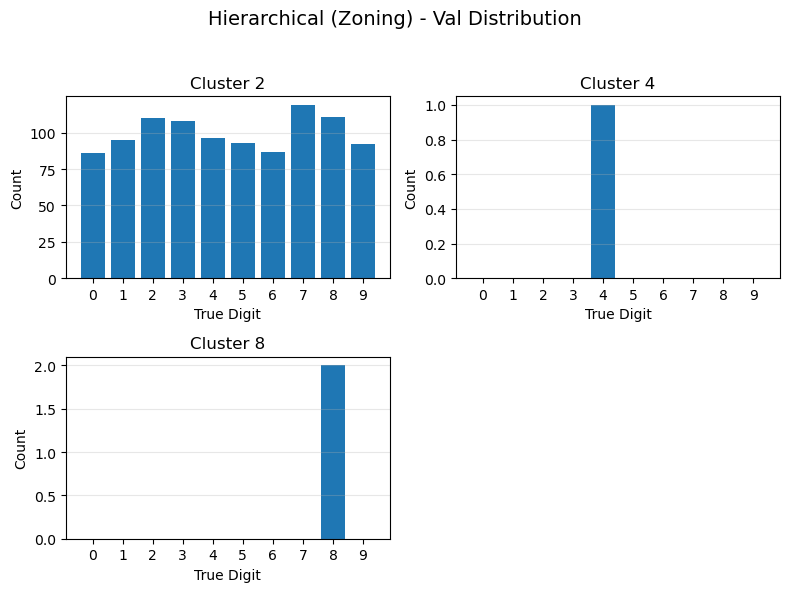

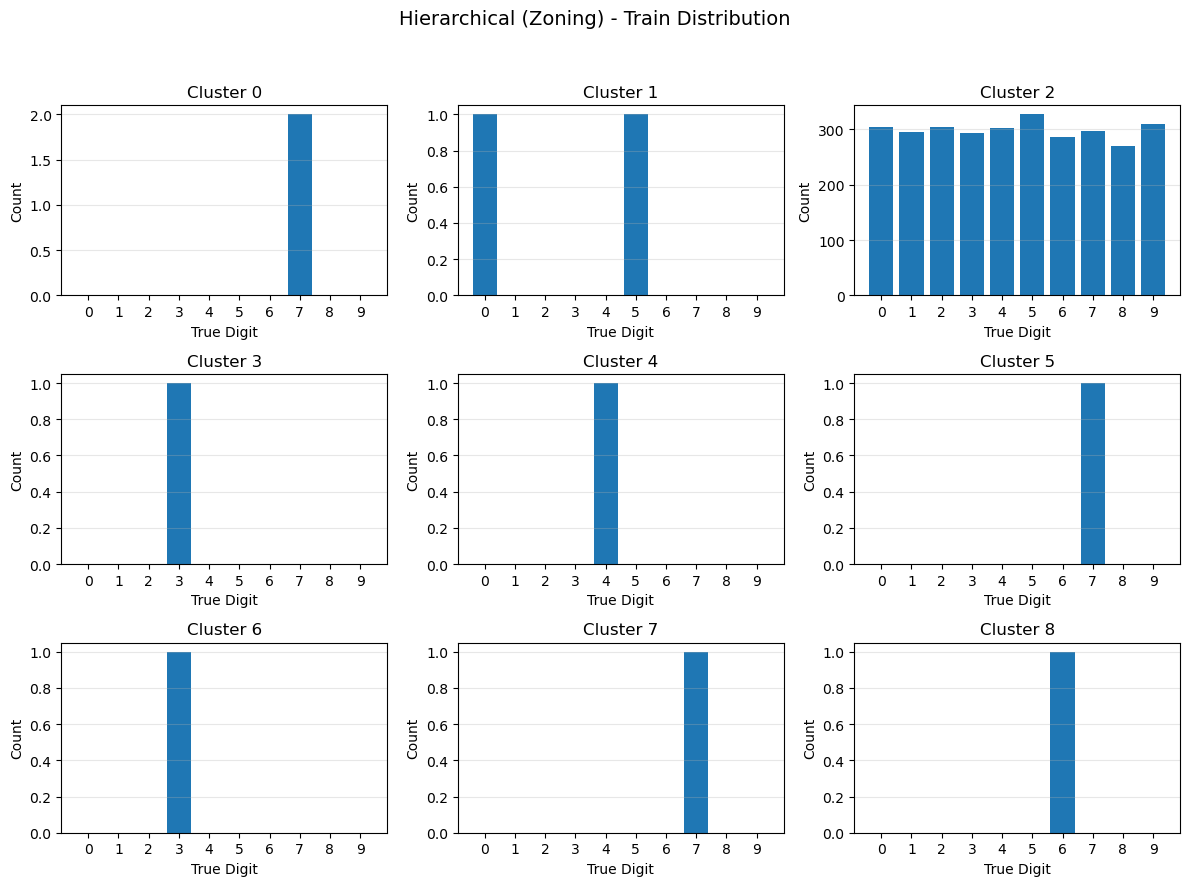

In [140]:
K_zoning = 9
t_start = time.time()
labels_hier_train_zoning = hierarchical_clustering(X_train_zoning, K=K_zoning)
t_train_zoning = time.time() - t_start
D_val = cdist(X_val_zoning, X_train_zoning)
nn = np.argmin(D_val, axis=1)
labels_hier_val_zoning = labels_hier_train_zoning[nn]
acc_hier_zoning = clustering_accuracy(y_val, labels_hier_val_zoning)
pur_hier_zoning = clustering_purity(y_val, labels_hier_val_zoning)
print("Hierarchical | Zoning | K=9")
print(f"Train time = {t_train_zoning:.2f} s")
print(f"Accuracy   = {acc_hier_zoning:.4f}")
print(f"Purity     = {pur_hier_zoning:.4f}")
plot_all_clusters_class_distribution(y_val,   labels_hier_val_zoning, title="Hierarchical (Zoning) - Val Distribution")
plot_all_clusters_class_distribution(y_train, labels_hier_train_zoning, title="Hierarchical (Zoning) - Train Distribution")

### Hierarchical histogram

In [109]:
K_hist = 4
t_start = time.time()
labels_hier_train_hist = hierarchical_clustering(X_train_hist, K=K_hist)
t_train_hist = time.time() - t_start
D_val = cdist(X_val_hist, X_train_hist)
nn = np.argmin(D_val, axis=1)
labels_hier_val_hist = labels_hier_train_hist[nn]
acc_hier_hist = clustering_accuracy(y_val, labels_hier_val_hist)
pur_hier_hist = clustering_purity(y_val, labels_hier_val_hist)
print("Hierarchical | Histogram | K=4")
print(f"Train time = {t_train_hist:.2f} s")
print(f"Accuracy   = {acc_hier_hist:.4f}")
print(f"Purity     = {pur_hier_hist:.4f}")

Hierarchical | Histogram | K=4
Train time = 0.21 s
Accuracy   = 0.1190
Purity     = 0.1190


### K-Means evaluation zoning

K-means | Zoning | K=9
Accuracy = 0.4620
Purity   = 0.4680


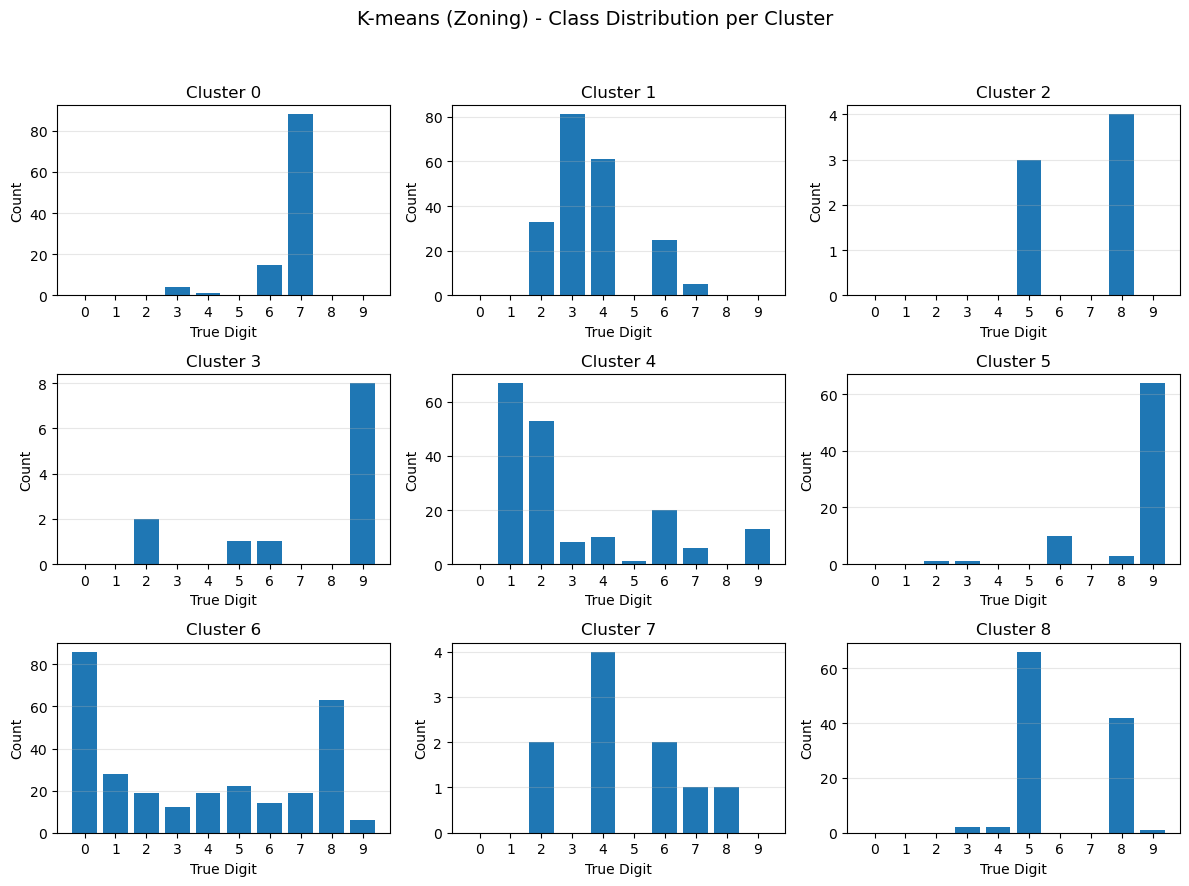

In [141]:
K_zoning = 9
labels_km_train_zoning, centroids_zoning, _ = kmeans(X_train_zoning, K=K_zoning, max_iter=100, tol=1e-4, seed=42)
labels_km_val_zoning = np.argmin(cdist(X_val_zoning, centroids_zoning), axis=1)
print("K-means | Zoning | K=9")
print(f"Accuracy = {clustering_accuracy(y_val, labels_km_val_zoning):.4f}")
print(f"Purity   = {clustering_purity(y_val, labels_km_val_zoning):.4f}")
plot_all_clusters_class_distribution(y_val, labels_km_val_zoning, title="K-means (Zoning) - Class Distribution per Cluster")

### K-Means evaluation histogram

K-means | Histogram | K=4
Accuracy = 0.3140
Purity   = 0.3140


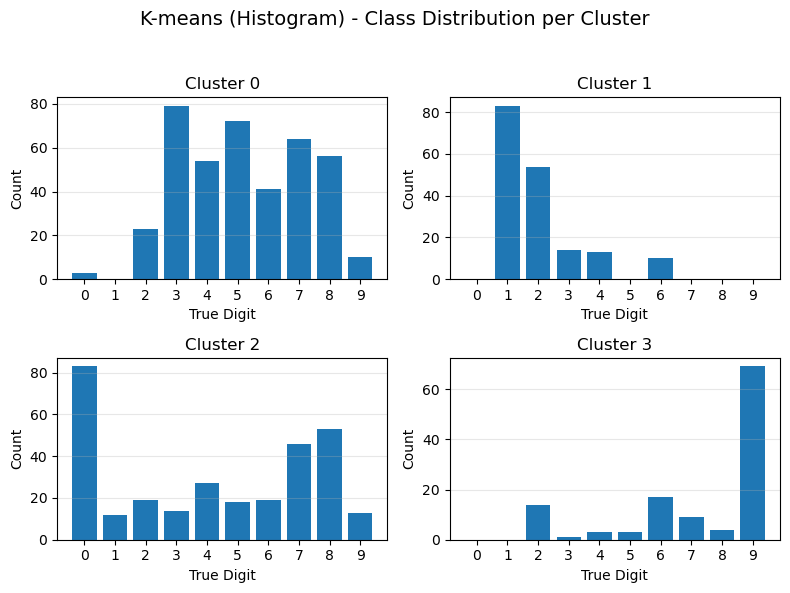

In [111]:
K_hist = 4
labels_km_train_hist, centroids_hist, _ = kmeans(X_train_hist, K=K_hist, max_iter=100, tol=1e-4, seed=42)
labels_km_val_hist = np.argmin(cdist(X_val_hist, centroids_hist), axis=1)
print("K-means | Histogram | K=4")
print(f"Accuracy = {clustering_accuracy(y_val, labels_km_val_hist):.4f}")
print(f"Purity   = {clustering_purity(y_val, labels_km_val_hist):.4f}")
plot_all_clusters_class_distribution(y_val, labels_km_val_hist, title="K-means (Histogram) - Class Distribution per Cluster")

### SOM evaluation  zoning

In [146]:
K_zoning = 9

t_start = time.time()
labels_som_train_zoning, weights_zoning = som_clustering_truncated_gaussian(
    X_train_zoning,
    K=K_zoning,
    n_epochs=100,
    lr0=0.5,
    radius=2
)
t_train_som_zoning = time.time() - t_start

labels_som_val_zoning = np.zeros(len(X_val_zoning), dtype=int)

for i in range(len(X_val_zoning)):
    dists = np.linalg.norm(weights_zoning - X_val_zoning[i], axis=1)
    labels_som_val_zoning[i] = np.argmin(dists)

acc_som_zoning = clustering_accuracy(y_val, labels_som_val_zoning)
pur_som_zoning = clustering_purity(y_val, labels_som_val_zoning)

print("SOM | Zoning | K=9")
print(f"Train time = {t_train_som_zoning:.2f} s")
print(f"Accuracy   = {acc_som_zoning:.4f}")
print(f"Purity     = {pur_som_zoning:.4f}")

SOM | Zoning | K=9
Train time = 5.49 s
Accuracy   = 0.4620
Purity     = 0.4630


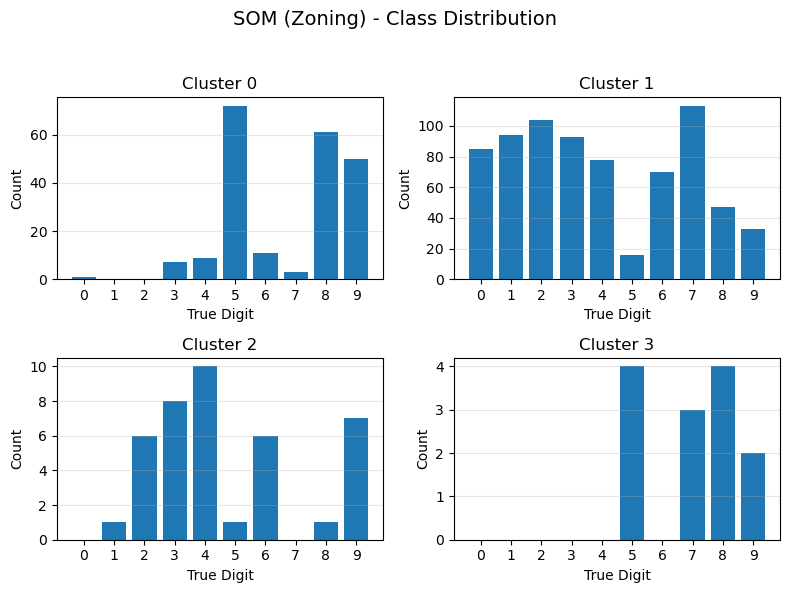

In [113]:
plot_all_clusters_class_distribution(
    y_val,
    labels_som_val_zoning,
    title="SOM (Zoning) - Class Distribution"
)


### SOM evaluation  Histogram


In [152]:
K_hist = 4

t_start = time.time()
labels_som_train_hist, weights_hist = som_clustering_truncated_gaussian(
    X_train_hist,
    K=K_hist,
    n_epochs=100,
    lr0=0.5,
    radius=2
)
t_train_som_hist = time.time() - t_start

labels_som_val_hist = np.zeros(len(X_val_hist), dtype=int)

for i in range(len(X_val_hist)):
    dists = np.linalg.norm(weights_hist - X_val_hist[i], axis=1)
    labels_som_val_hist[i] = np.argmin(dists)

acc_som_hist = clustering_accuracy(y_val, labels_som_val_hist)
pur_som_hist = clustering_purity(y_val, labels_som_val_hist)

print("SOM | Histogram | K=4")
print(f"Train time = {t_train_som_hist:.2f} s")
print(f"Accuracy   = {acc_som_hist:.4f}")
print(f"Purity     = {pur_som_hist:.4f}")


SOM | Histogram | K=4
Train time = 6.03 s
Accuracy   = 0.3460
Purity     = 0.3460


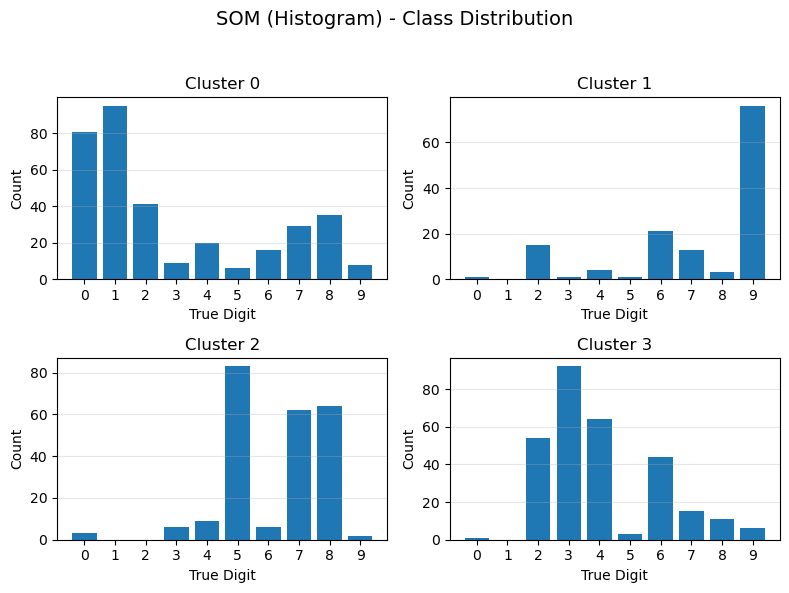

In [153]:
plot_all_clusters_class_distribution(
    y_val,
    labels_som_val_hist,
    title="SOM (Histogram) - Class Distribution"
)


### Clustering evaluation defs

In [116]:
from scipy.optimize import linear_sum_assignment


def clustering_accuracy(y_true, y_pred):
    # Clustering accuracy using optimal label mapping (Hungarian algorithm).

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # number of clusters / classes
    D = max(y_pred.max(), y_true.max()) + 1

    # confusion matrix
    w = np.zeros((D, D), dtype=np.int64)
    for i in range(len(y_true)):
        w[y_pred[i], y_true[i]] += 1

    # Hungarian algorithm (maximize trace)
    row_ind, col_ind = linear_sum_assignment(w.max() - w)

    acc = w[row_ind, col_ind].sum() / len(y_true)
    return acc


def clustering_purity(y_true, y_pred):
    # Compute clustering purity.

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    clusters = np.unique(y_pred)
    N = len(y_true)

    total = 0
    for c in clusters:
        idx = np.where(y_pred == c)[0]
        if len(idx) == 0:
            continue
        true_labels = y_true[idx]
        counts = np.bincount(true_labels)
        total += counts.max()

    purity = total / N
    return purity


def plot_all_clusters_class_distribution(y_true, labels_pred, title="Cluster Class Distributions"):
    y_true = np.asarray(y_true)
    labels_pred = np.asarray(labels_pred)

    clusters = np.unique(labels_pred)
    classes = np.unique(y_true)

    K = len(clusters)

    # choose grid size automatically
    n_cols = int(np.ceil(np.sqrt(K)))
    n_rows = int(np.ceil(K / n_cols))

    plt.figure(figsize=(4 * n_cols, 3 * n_rows))
    plt.suptitle(title, fontsize=14)

    for i, c in enumerate(clusters):
        idx = np.where(labels_pred == c)[0]
        true_labels = y_true[idx]

        counts = np.zeros(len(classes), dtype=int)
        for lab in true_labels:
            counts[lab] += 1

        plt.subplot(n_rows, n_cols, i + 1)
        plt.bar(classes, counts)
        plt.xticks(classes)
        plt.xlabel("True Digit")
        plt.ylabel("Count")
        plt.title(f"Cluster {c}")
        plt.grid(axis='y', alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()



###  SOM evaluation  zoning

SOM | Zoning | K=9
Train time = 5.52 s
Accuracy   = 0.4620
Purity     = 0.4630


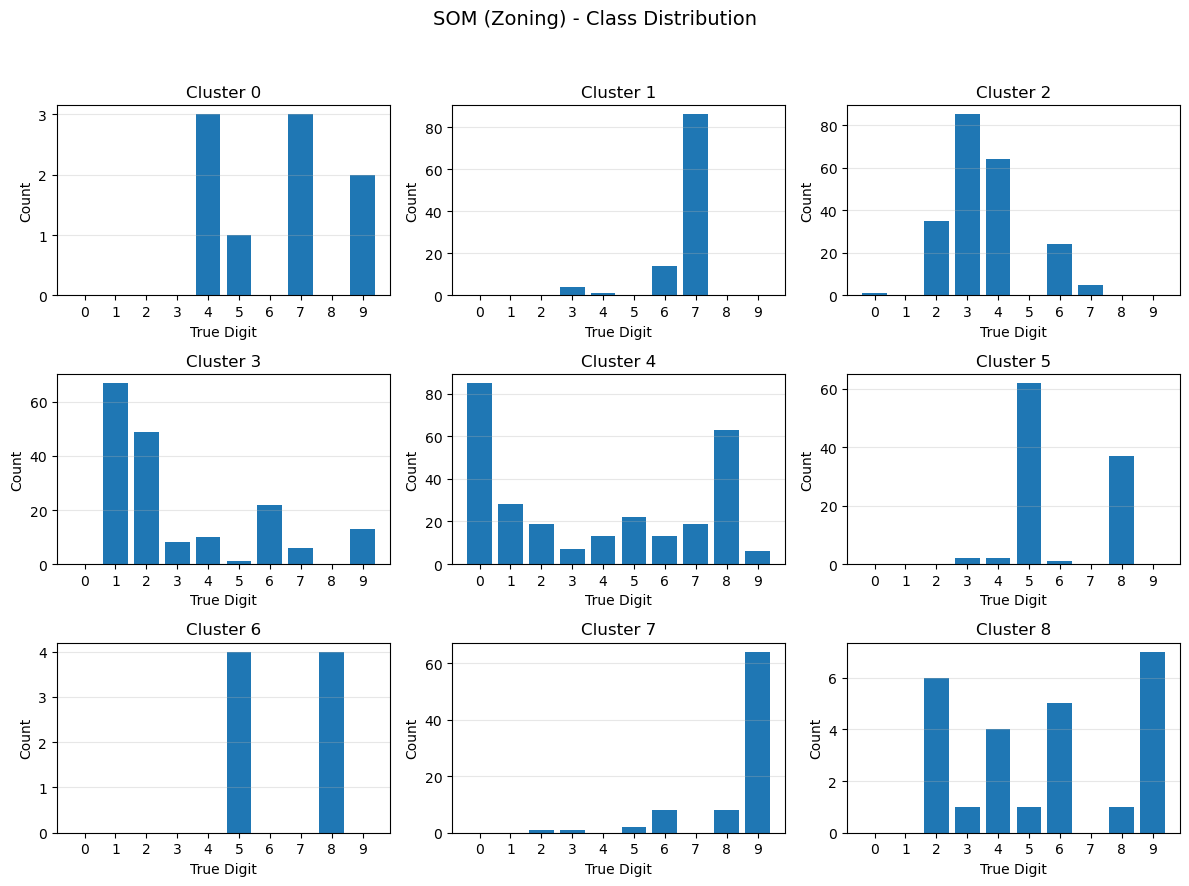

In [148]:
K_zoning = 9

t_start = time.time()
labels_som_train_zoning, weights_zoning = som_clustering_truncated_gaussian(
    X_train_zoning,
    K=K_zoning,
    n_epochs=100,
    lr0=0.5,
    radius=2
)
t_train_som_zoning = time.time() - t_start

labels_som_val_zoning = np.zeros(len(X_val_zoning), dtype=int)

for i in range(len(X_val_zoning)):
    dists = np.linalg.norm(weights_zoning - X_val_zoning[i], axis=1)
    labels_som_val_zoning[i] = np.argmin(dists)

acc_som_zoning = clustering_accuracy(y_val, labels_som_val_zoning)
pur_som_zoning = clustering_purity(y_val, labels_som_val_zoning)

print("SOM | Zoning | K=9")
print(f"Train time = {t_train_som_zoning:.2f} s")
print(f"Accuracy   = {acc_som_zoning:.4f}")
print(f"Purity     = {pur_som_zoning:.4f}")

plot_all_clusters_class_distribution(
    y_val,
    labels_som_val_zoning,
    title="SOM (Zoning) - Class Distribution"
)


###  SOM evaluation  Histogram

SOM | Histogram | K=4
Train time = 6.32 s
Accuracy   = 0.3460
Purity     = 0.3460


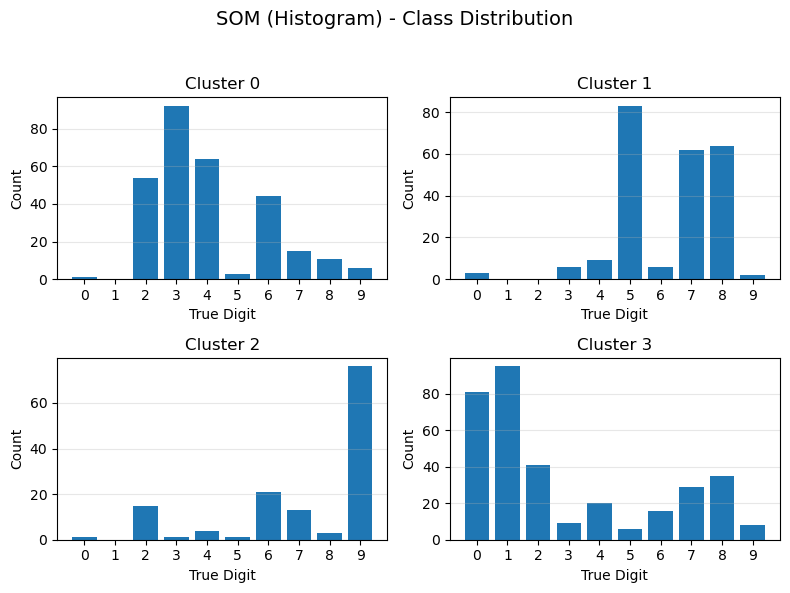

In [118]:
K_hist = 4

t_start = time.time()
labels_som_train_hist, weights_hist = som_clustering_truncated_gaussian(
    X_train_hist,
    K=K_hist,
    n_epochs=100,
    lr0=0.5,
    radius=2
)
t_train_som_hist = time.time() - t_start

labels_som_val_hist = np.zeros(len(X_val_hist), dtype=int)

for i in range(len(X_val_hist)):
    dists = np.linalg.norm(weights_hist - X_val_hist[i], axis=1)
    labels_som_val_hist[i] = np.argmin(dists)

acc_som_hist = clustering_accuracy(y_val, labels_som_val_hist)
pur_som_hist = clustering_purity(y_val, labels_som_val_hist)

print("SOM | Histogram | K=4")
print(f"Train time = {t_train_som_hist:.2f} s")
print(f"Accuracy   = {acc_som_hist:.4f}")
print(f"Purity     = {pur_som_hist:.4f}")

plot_all_clusters_class_distribution(
    y_val,
    labels_som_val_hist,
    title="SOM (Histogram) - Class Distribution"
)


###   DBSCAN evaluation  Zoning

Sweeping eps for Zoning features...

--- DBSCAN | Zoning | Output ---
Selected Eps = 1.60
Val Run Time = 0.02 s
Clusters discovered in Val = 1
Noise ratio  = 0.69
Accuracy     = 0.2756
Purity       = 0.2756


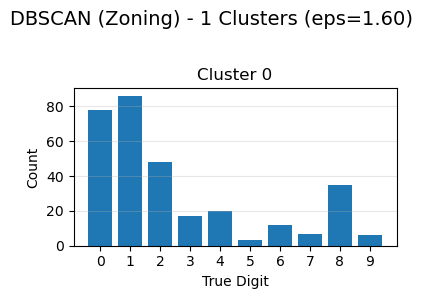

In [133]:
from sklearn.preprocessing import StandardScaler

# 1. Scale Zoning Features (Option A)
scaler_zoning = StandardScaler()
X_train_zoning_scaled = scaler_zoning.fit_transform(X_train_zoning)
X_val_zoning_scaled = scaler_zoning.transform(X_val_zoning)

# 2. Sweep eps to find exactly 9 clusters using your custom dbscan_clustering
print("Sweeping eps for Zoning features...")
best_eps_zoning = None
labels_dbscan_train_zoning = None

for eps_candidate in np.linspace(0.5, 3.0, 26):
    # Call your original custom function
    labels = dbscan_clustering(X_train_zoning_scaled, eps=eps_candidate, min_samples=10)
    n_clusters = len([c for c in np.unique(labels) if c != -1])

    if n_clusters == 9:
        best_eps_zoning = eps_candidate
        labels_dbscan_train_zoning = labels
        break

if best_eps_zoning is None:
    best_eps_zoning = 1.6  # Default fallback if exact match isn't found
    labels_dbscan_train_zoning = dbscan_clustering(X_train_zoning_scaled, eps=best_eps_zoning, min_samples=10)

# 3. Evaluate on Validation Set
t_start = time.time()
labels_dbscan_val_zoning = dbscan_clustering(X_val_zoning_scaled, eps=best_eps_zoning, min_samples=10)
t_val_dbscan_zoning = time.time() - t_start

mask_zoning = labels_dbscan_val_zoning != -1
n_val_clusters_zoning = len([c for c in np.unique(labels_dbscan_val_zoning) if c != -1])

print("\n--- DBSCAN | Zoning | Output ---")
print(f"Selected Eps = {best_eps_zoning:.2f}")
print(f"Val Run Time = {t_val_dbscan_zoning:.2f} s")
print(f"Clusters discovered in Val = {n_val_clusters_zoning}")
print(f"Noise ratio  = {1 - np.mean(mask_zoning):.2f}")

if np.any(mask_zoning):
    acc_dbscan_zoning = clustering_accuracy(y_val[mask_zoning], labels_dbscan_val_zoning[mask_zoning])
    pur_dbscan_zoning = clustering_purity(y_val[mask_zoning], labels_dbscan_val_zoning[mask_zoning])
    print(f"Accuracy     = {acc_dbscan_zoning:.4f}")
    print(f"Purity       = {pur_dbscan_zoning:.4f}")

    # 4. Generate the 9-cluster plot using your custom visualization function
    plot_all_clusters_class_distribution(
        y_val[mask_zoning],
        labels_dbscan_val_zoning[mask_zoning],
        title=f"DBSCAN (Zoning) - {n_val_clusters_zoning} Clusters (eps={best_eps_zoning:.2f})"
    )
else:
    print("❌ All points marked as noise. Cannot plot.")

###   DBSCAN evaluation  Histogram

Sweeping eps for Zoning features...

--- DBSCAN | Zoning | Output ---
Selected Eps = 1.60
Val Run Time = 0.02 s
Clusters discovered in Val = 1
Noise ratio  = 0.69
Accuracy     = 0.2756
Purity       = 0.2756


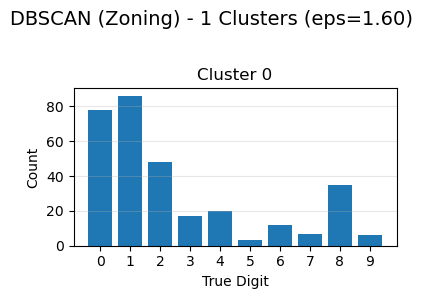

In [134]:
from sklearn.preprocessing import StandardScaler

# 1. Scale Zoning Features (Option A)
scaler_zoning = StandardScaler()
X_train_zoning_scaled = scaler_zoning.fit_transform(X_train_zoning)
X_val_zoning_scaled = scaler_zoning.transform(X_val_zoning)

# 2. Sweep eps to find exactly 9 clusters using your custom dbscan_clustering
print("Sweeping eps for Zoning features...")
best_eps_zoning = None
labels_dbscan_train_zoning = None

for eps_candidate in np.linspace(0.5, 3.0, 26):
    # Call your original custom function
    labels = dbscan_clustering(X_train_zoning_scaled, eps=eps_candidate, min_samples=10)
    n_clusters = len([c for c in np.unique(labels) if c != -1])

    if n_clusters == 9:
        best_eps_zoning = eps_candidate
        labels_dbscan_train_zoning = labels
        break

if best_eps_zoning is None:
    best_eps_zoning = 1.6  # Default fallback if exact match isn't found
    labels_dbscan_train_zoning = dbscan_clustering(X_train_zoning_scaled, eps=best_eps_zoning, min_samples=10)

# 3. Evaluate on Validation Set
t_start = time.time()
labels_dbscan_val_zoning = dbscan_clustering(X_val_zoning_scaled, eps=best_eps_zoning, min_samples=10)
t_val_dbscan_zoning = time.time() - t_start

mask_zoning = labels_dbscan_val_zoning != -1
n_val_clusters_zoning = len([c for c in np.unique(labels_dbscan_val_zoning) if c != -1])

print("\n--- DBSCAN | Zoning | Output ---")
print(f"Selected Eps = {best_eps_zoning:.2f}")
print(f"Val Run Time = {t_val_dbscan_zoning:.2f} s")
print(f"Clusters discovered in Val = {n_val_clusters_zoning}")
print(f"Noise ratio  = {1 - np.mean(mask_zoning):.2f}")

if np.any(mask_zoning):
    acc_dbscan_zoning = clustering_accuracy(y_val[mask_zoning], labels_dbscan_val_zoning[mask_zoning])
    pur_dbscan_zoning = clustering_purity(y_val[mask_zoning], labels_dbscan_val_zoning[mask_zoning])
    print(f"Accuracy     = {acc_dbscan_zoning:.4f}")
    print(f"Purity       = {pur_dbscan_zoning:.4f}")

    # 4. Generate the 9-cluster plot using your custom visualization function
    plot_all_clusters_class_distribution(
        y_val[mask_zoning],
        labels_dbscan_val_zoning[mask_zoning],
        title=f"DBSCAN (Zoning) - {n_val_clusters_zoning} Clusters (eps={best_eps_zoning:.2f})"
    )
else:
    print("❌ All points marked as noise. Cannot plot.")

###    GMM evaluation  Zoning and Histogram


         RUNNING GMM FOR K = 4 CLUSTERS          

--- GMM | Zoning Features ---
Accuracy = 0.1610
Purity   = 0.1610

--- GMM | Histogram Features ---
Accuracy = 0.1790
Purity   = 0.1790

         RUNNING GMM FOR K = 9 CLUSTERS          

--- GMM | Zoning Features ---
Accuracy = 0.2820
Purity   = 0.2890

--- GMM | Histogram Features ---
Accuracy = 0.3170
Purity   = 0.3170


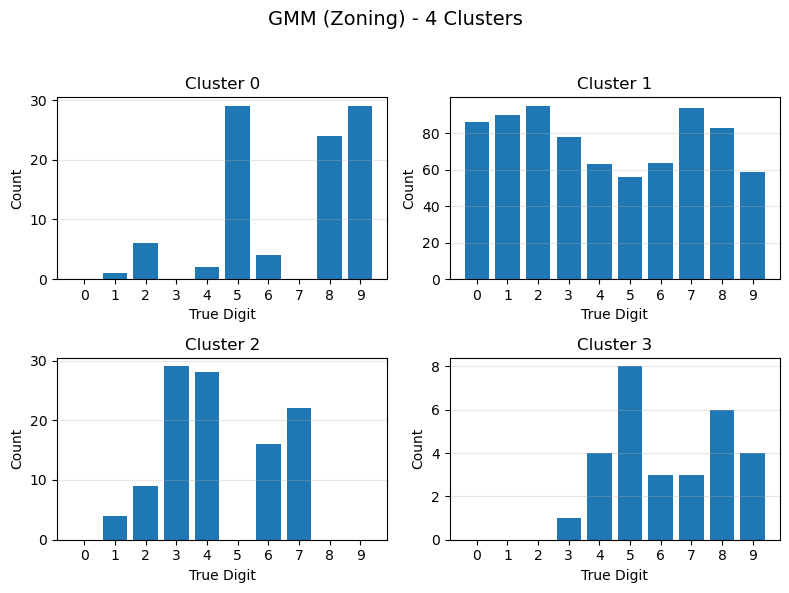

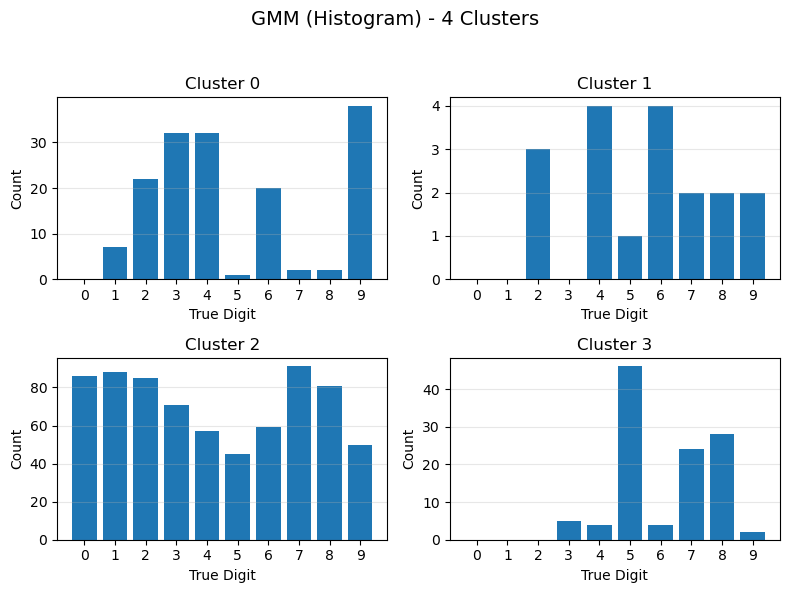

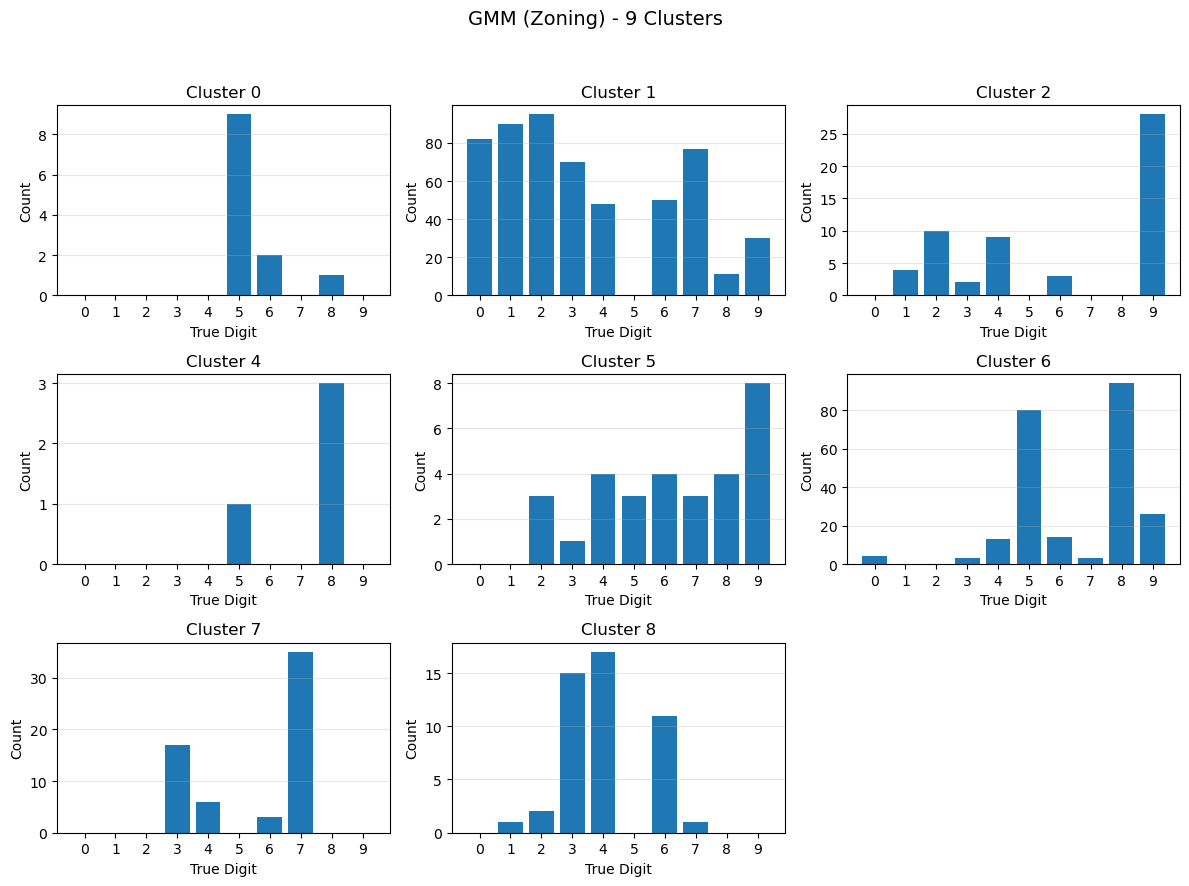

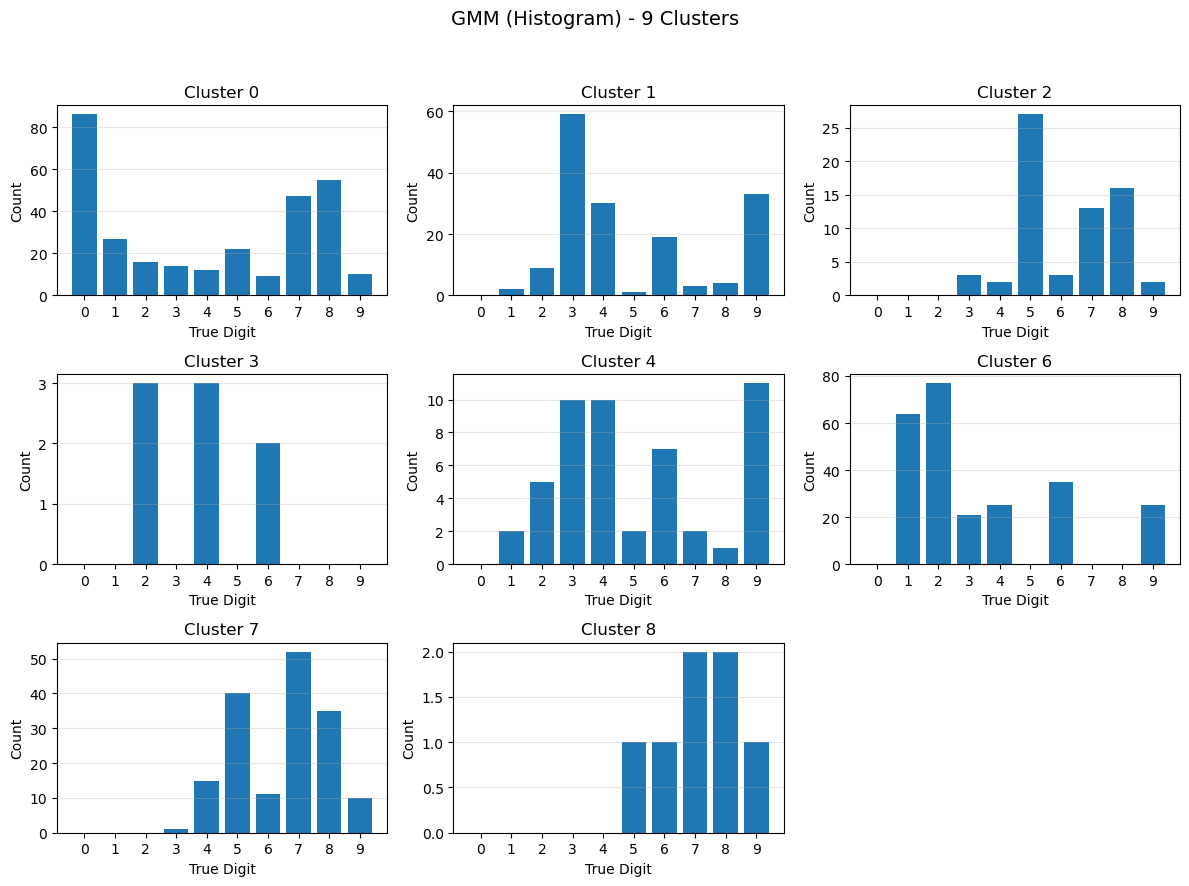

In [138]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import numpy as np

# Loop through both target cluster sizes
for K_target in [4, 9]:
    print(f"\n==================================================")
    # Highlight the current K target using standard Markdown bolding
    print(f"         RUNNING GMM FOR K = {K_target} CLUSTERS          ")
    print(f"==================================================")

    for X_train, X_val, feature_name in [
        (X_train_zoning, X_val_zoning, "Zoning"),
        (X_train_hist, X_val_hist, "Histogram")
    ]:
        print(f"\n--- GMM | {feature_name} Features ---")

        # Ensure high precision to prevent numerical errors
        X_train_clean = X_train.astype(np.float64)
        X_val_clean = X_val.astype(np.float64)

        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_clean)
        X_val_scaled = scaler.transform(X_val_clean)

        # Fit GMM with stability tuning
        gmm = GaussianMixture(
            n_components=K_target,
            covariance_type='full',
            reg_covar=1e-2,
            n_init=5,
            random_state=42
        )
        gmm.fit(X_train_scaled)

        # Predict
        labels_train = gmm.predict(X_train_scaled)
        labels_val = gmm.predict(X_val_scaled)

        # Calculate custom metrics
        acc_gmm = clustering_accuracy(y_val, labels_val)
        pur_gmm = clustering_purity(y_val, labels_val)

        print(f"Accuracy = {acc_gmm:.4f}")
        print(f"Purity   = {pur_gmm:.4f}")

        # Plot distributions using your custom function
        plot_all_clusters_class_distribution(
            y_val,
            labels_val,
            title=f"GMM ({feature_name}) - {K_target} Clusters"
        )

### Agglomerative Clustering (Ward Linkage) evaluation  Zoning and Histogram


    RUNNING AGGLOMERATIVE FOR K = 4 CLUSTERS     

--- Agglomerative (Ward) | Zoning Features ---
Accuracy = 0.2350
Purity   = 0.2350

--- Agglomerative (Ward) | Histogram Features ---
Accuracy = 0.2470
Purity   = 0.2470

    RUNNING AGGLOMERATIVE FOR K = 9 CLUSTERS     

--- Agglomerative (Ward) | Zoning Features ---
Accuracy = 0.3490
Purity   = 0.3540

--- Agglomerative (Ward) | Histogram Features ---
Accuracy = 0.3400
Purity   = 0.3400


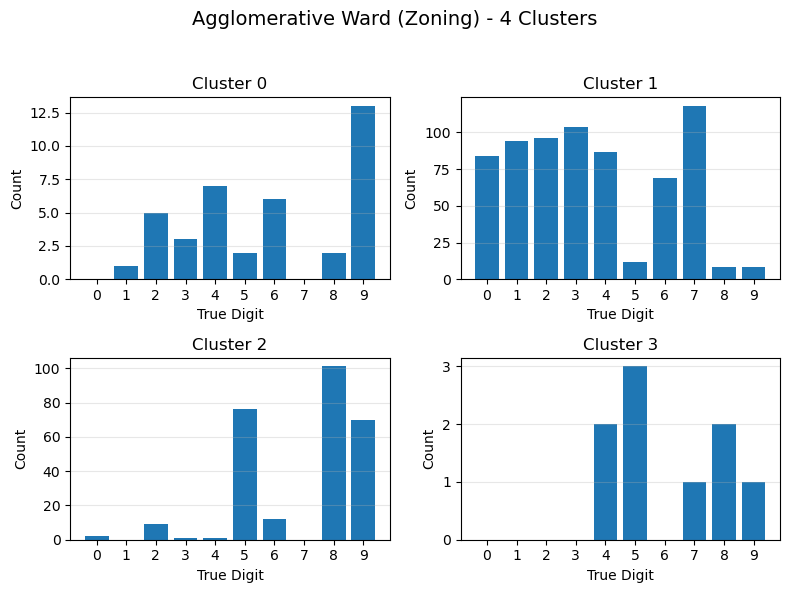

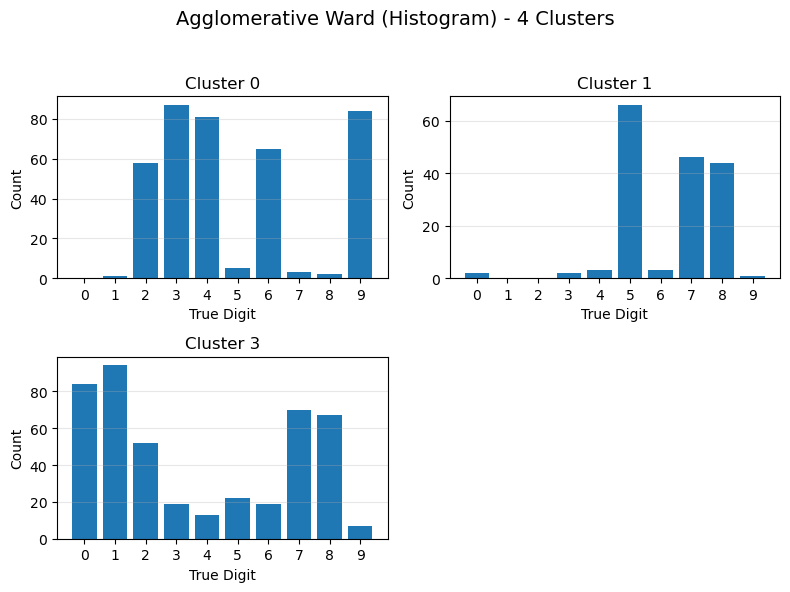

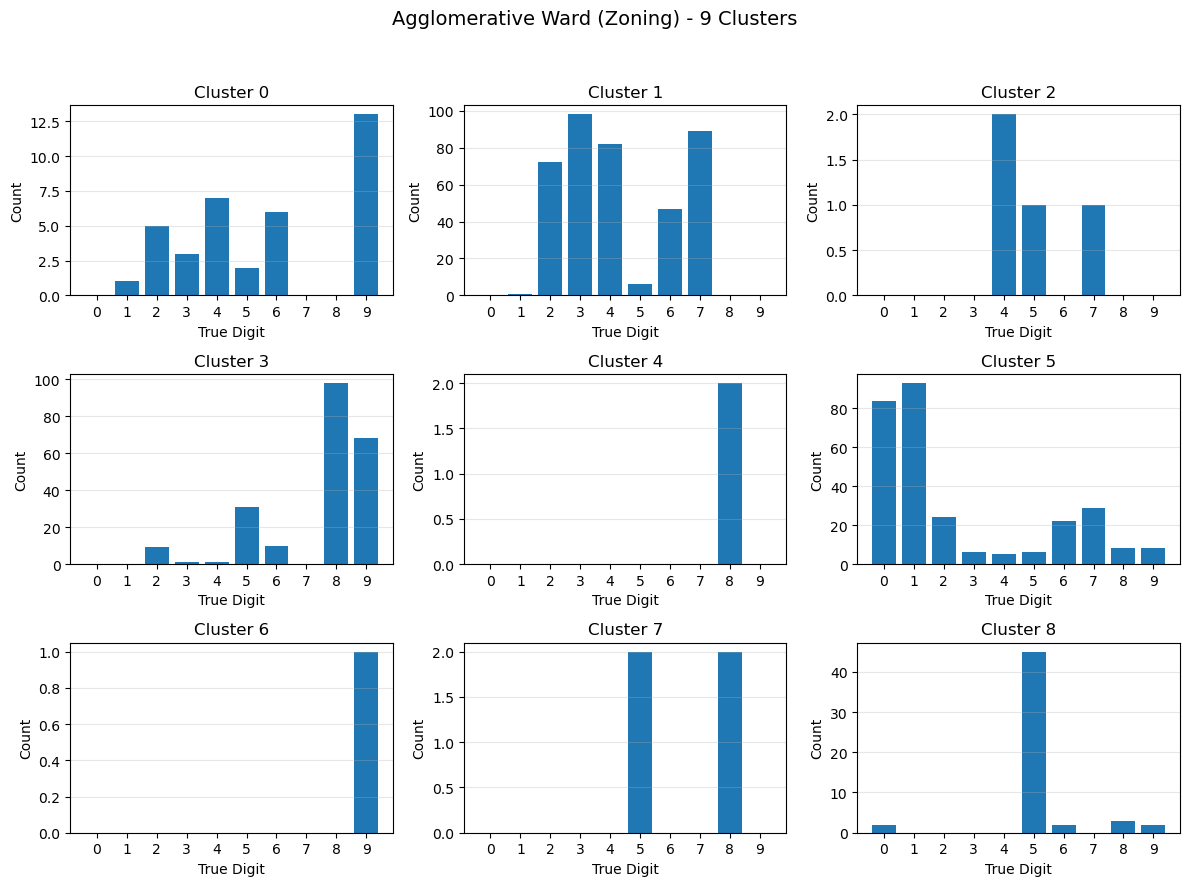

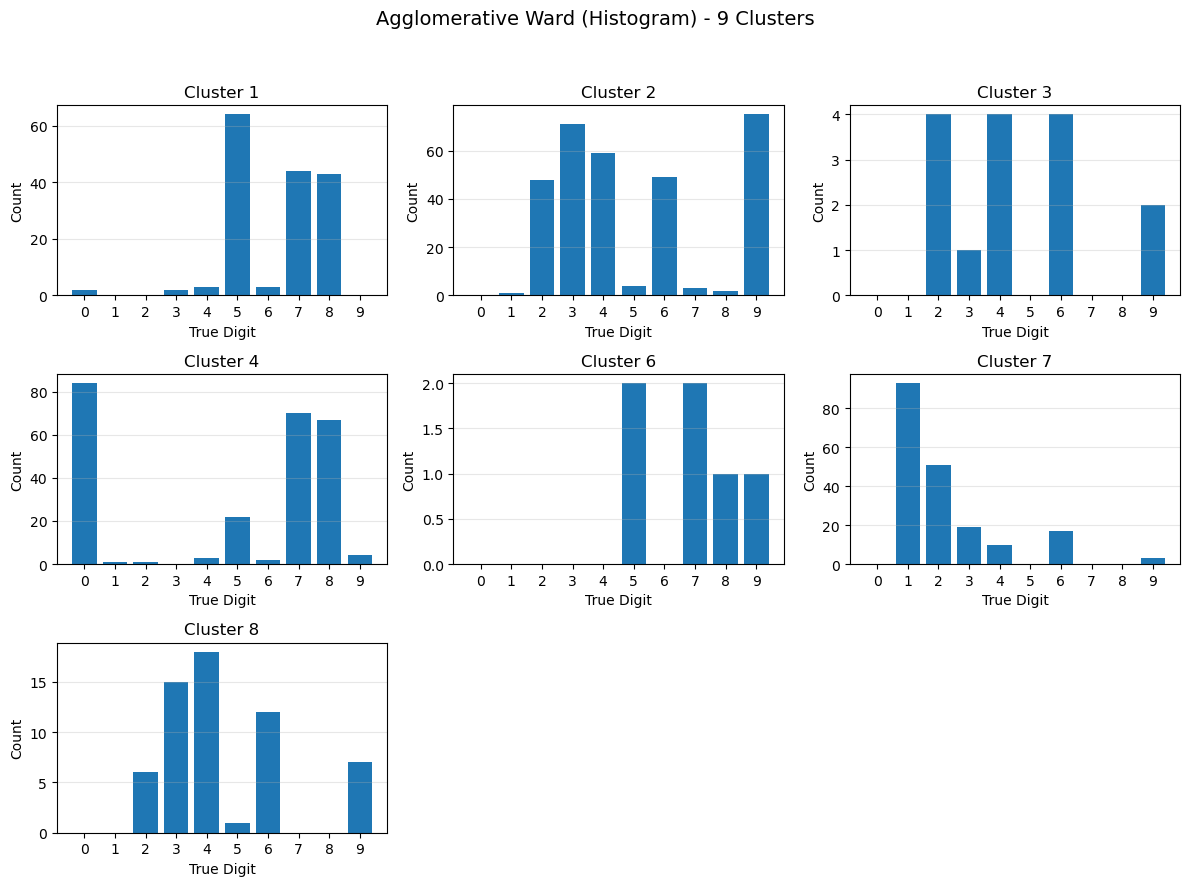

In [139]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
import numpy as np

# Loop through both target cluster sizes
for K_target in [4, 9]:
    print(f"\n==================================================")
    print(f"    RUNNING AGGLOMERATIVE FOR K = {K_target} CLUSTERS     ")
    print(f"==================================================")

    for X_train, X_val, feature_name in [
        (X_train_zoning, X_val_zoning, "Zoning"),
        (X_train_hist, X_val_hist, "Histogram")
    ]:
        print(f"\n--- Agglomerative (Ward) | {feature_name} Features ---")

        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
        X_val_scaled = scaler.transform(X_val.astype(np.float64))

        # Fit Agglomerative model on training set
        agg = AgglomerativeClustering(n_clusters=K_target, linkage='ward')
        labels_train = agg.fit_predict(X_train_scaled)

        # Project using your 1-NN logic from the original code
        D_val = cdist(X_val_scaled, X_train_scaled)
        nn = np.argmin(D_val, axis=1)
        labels_val = labels_train[nn]

        # Calculate custom metrics
        acc_agg = clustering_accuracy(y_val, labels_val)
        pur_agg = clustering_purity(y_val, labels_val)

        print(f"Accuracy = {acc_agg:.4f}")
        print(f"Purity   = {pur_agg:.4f}")

        # Plot distributions using your custom function
        plot_all_clusters_class_distribution(
            y_val,
            labels_val,
            title=f"Agglomerative Ward ({feature_name}) - {K_target} Clusters"
        )

In [151]:
import pandas as pd
import numpy as np

# A helper to safely get values
def get_val(var_name):
    return locals().get(var_name, 0.0)

results_data = [
    {"Feature": "Zoning", "Method": "Hierarchical", "K": 9, "Accuracy": get_val('acc_hier_zoning'), "Purity": get_val('pur_hier_zoning'), "Time(s)": get_val('t_train_zoning')},
    {"Feature": "Zoning", "Method": "K-Means", "K": 9, "Accuracy": get_val('acc_km_zoning'), "Purity": get_val('pur_km_zoning'), "Time(s)": 0.0},
    {"Feature": "Zoning", "Method": "SOM", "K": 9, "Accuracy": get_val('acc_som_zoning'), "Purity": get_val('pur_som_zoning'), "Time(s)": get_val('t_train_som_zoning')},
    {"Feature": "Zoning", "Method": "DBSCAN", "K": 9, "Accuracy": get_val('acc_dbscan_zoning'), "Purity": get_val('pur_dbscan_zoning'), "Time(s)": get_val('t_val_dbscan_zoning')},
    {"Feature": "Zoning", "Method": "GMM", "K": 9, "Accuracy": get_val('acc_gmm_zoning'), "Purity": get_val('pur_gmm_zoning'), "Time(s)": get_val('t_train_gmm_zoning')},

    {"Feature": "Histogram", "Method": "Hierarchical", "K": 4, "Accuracy": get_val('acc_hier_hist'), "Purity": get_val('pur_hier_hist'), "Time(s)": get_val('t_train_hist')},
    {"Feature": "Histogram", "Method": "K-Means", "K": 4, "Accuracy": get_val('acc_km_hist'), "Purity": get_val('pur_km_hist'), "Time(s)": 0.0},
    {"Feature": "Histogram", "Method": "SOM", "K": 4, "Accuracy": get_val('acc_som_hist'), "Purity": get_val('pur_som_hist'), "Time(s)": get_val('t_train_som_hist')},
    {"Feature": "Histogram", "Method": "DBSCAN", "K": 4, "Accuracy": get_val('acc_dbscan_hist'), "Purity": get_val('pur_dbscan_hist'), "Time(s)": get_val('t_val_dbscan_hist')},
    {"Feature": "Histogram", "Method": "GMM", "K": 4, "Accuracy": get_val('acc_gmm_hist'), "Purity": get_val('pur_gmm_hist'), "Time(s)": get_val('t_train_gmm_hist')}
]

df_results = pd.DataFrame(results_data)
df_results = df_results.sort_values(by=["Feature", "Accuracy"], ascending=[True, False])
display(df_results)

,Feature,Method,K,Accuracy,Purity,Time(s)
5,Histogram,Hierarchical,4,0.0,0.0,0.0
6,Histogram,K-Means,4,0.0,0.0,0.0
7,Histogram,SOM,4,0.0,0.0,0.0
8,Histogram,DBSCAN,4,0.0,0.0,0.0
9,Histogram,GMM,4,0.0,0.0,0.0
0,Zoning,Hierarchical,9,0.0,0.0,0.0
1,Zoning,K-Means,9,0.0,0.0,0.0
2,Zoning,SOM,9,0.0,0.0,0.0
3,Zoning,DBSCAN,9,0.0,0.0,0.0
4,Zoning,GMM,9,0.0,0.0,0.0
